# DL Midterm Project: BraTS 2D Binary Baseline

This notebook is the learning/inspection layer.
- Check environment and paths
- Load one BraTS case from `BraTS2021_00495.tar`
- Visualize MRI + tumor mask slices
- Build 2D binary slices (`X`, `y`) for training

Production training code lives in Python scripts: `data.py`, `dataset.py`, `model.py`, `losses.py`, `eval.py`, `train.py`.


In [1]:
import sys, os
from pathlib import Path

# --- Environment setup ---
# All data, scripts, and pre-trained results are included in the repo.
# Just clone and run: git clone https://github.com/adilsult/dl_segmentation.git

PROJECT_DIR = Path(".")

# Verify all required files are present
required_files = [
    "BraTS2021_00495.tar",
    "BraTS2021_00621.tar",
    "data.py", "dataset.py", "model.py", "losses.py", "eval.py",
    "train.py", "compare_models.py",
    "runs/baseline_2d_e20/history.json",
    "runs/baseline_2d_e20/best.pt",
    "runs/unet_dicebce/history.json",
    "runs/attn_dicebce/history.json",
    "runs/hybrid_dicebce/history.json",
    "runs/hybrid_focal_tversky/history.json",
]

missing = [f for f in required_files if not (PROJECT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {len(missing)} file(s): {missing}\n"
        "Please clone the full repo:\n"
        "  git clone https://github.com/adilsult/dl_segmentation.git"
    )

print(f"All {len(required_files)} required files present.")
print("Python:", sys.executable)
print("Working dir:", Path.cwd())

All 15 required files present.
Python: /Users/adilsultankhairolla/Documents/mri project/.venv/bin/python
Working dir: /Users/adilsultankhairolla/Documents/mri project


In [2]:
# Run only if packages are missing in your .venv kernel
# %pip install nibabel numpy matplotlib torch


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from data import load_case_volumes, normalize_modalities, to_binary_mask, find_tumor_slices, build_slices
from dataset import make_loaders
from model import UNet2D, AttentionUNet2D, HybridUNet2D
from losses import DiceBCELoss, FocalTverskyLoss

In [4]:
case_path = PROJECT_DIR / "BraTS2021_00495.tar"
assert case_path.exists(), f'Missing file: {case_path.resolve()}'
print('Case source:', case_path.resolve())


Case source: /Users/adilsultankhairolla/Documents/mri project/BraTS2021_00495.tar


In [5]:
volumes = load_case_volumes(case_path)
for k, v in volumes.items():
    print(f'{k}: shape={v.shape}, dtype={v.dtype}')

print('Original mask labels:', np.unique(volumes['seg']))


t1: shape=(240, 240, 155), dtype=float32
t1ce: shape=(240, 240, 155), dtype=float32
t2: shape=(240, 240, 155), dtype=float32
flair: shape=(240, 240, 155), dtype=float32
seg: shape=(240, 240, 155), dtype=float32
Original mask labels: [0. 1. 2. 4.]


In [6]:
volumes = normalize_modalities(volumes)
binary_seg = to_binary_mask(volumes['seg'])
tumor_slices = find_tumor_slices(binary_seg)

print('Binary mask values:', np.unique(binary_seg))
print('Tumor-positive slices:', len(tumor_slices))
print('First 10 tumor slices:', tumor_slices[:10])


Binary mask values: [0. 1.]
Tumor-positive slices: 70
First 10 tumor slices: [66, 67, 68, 69, 70, 71, 72, 73, 74, 75]


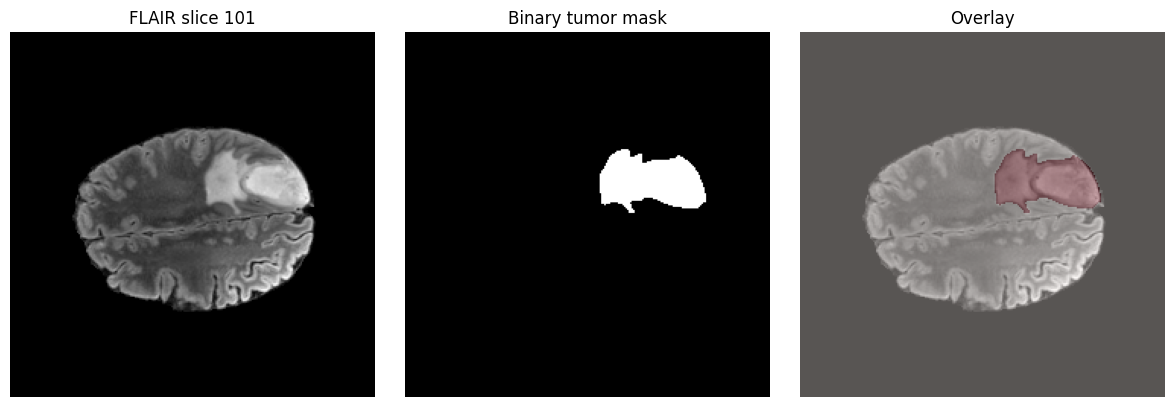

In [7]:
slice_idx = tumor_slices[len(tumor_slices) // 2]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(volumes['flair'][:, :, slice_idx], cmap='gray')
plt.title(f'FLAIR slice {slice_idx}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_seg[:, :, slice_idx], cmap='gray')
plt.title('Binary tumor mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(volumes['flair'][:, :, slice_idx], cmap='gray')
plt.imshow(binary_seg[:, :, slice_idx], cmap='Reds', alpha=0.35)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
X, y, used_indices = build_slices(volumes, only_tumor=True, return_indices=True)
print('X shape:', X.shape, 'dtype:', X.dtype)
print('y shape:', y.shape, 'dtype:', y.dtype)
print('y unique values:', np.unique(y))

# Contract checks
assert X.dtype == np.float32 and y.dtype == np.float32
assert X.ndim == 4 and y.ndim == 4
assert X.shape[1] == 4 and y.shape[1] == 1
assert set(np.unique(y).tolist()).issubset({0.0, 1.0})


X shape: (70, 4, 240, 240) dtype: float32
y shape: (70, 1, 240, 240) dtype: float32
y unique values: [0. 1.]


In [9]:
train_loader, val_loader = make_loaders(X, y, batch_size=4, val_ratio=0.2, seed=42)

xb, yb = next(iter(train_loader))
print('One train batch:', xb.shape, yb.shape, xb.dtype, yb.dtype)
print('Val loader is None?', val_loader is None)


One train batch: torch.Size([4, 4, 240, 240]) torch.Size([4, 1, 240, 240]) torch.float32 torch.float32
Val loader is None? False


In [10]:
import torch

# --- Sanity check: forward pass through all 3 architectures ---
for ModelClass, name in [(UNet2D, "UNet2D"),
                          (AttentionUNet2D, "AttentionUNet2D"),
                          (HybridUNet2D, "HybridUNet2D")]:
    if name == "HybridUNet2D":
        m = ModelClass(in_channels=4, out_channels=1, base_channels=16,
                       num_heads=4, num_transformer_layers=2, dim_feedforward=256)
    else:
        m = ModelClass(in_channels=4, out_channels=1, base_channels=16)
    n_params = sum(p.numel() for p in m.parameters())
    logits = m(xb)
    print(f"{name:20s} | params: {n_params:>10,} | output: {logits.shape}")

# Loss functions check
for LossClass, lname in [(DiceBCELoss, "DiceBCELoss"), (FocalTverskyLoss, "FocalTverskyLoss")]:
    loss_fn = LossClass()
    loss_val = loss_fn(logits, yb)
    print(f"{lname:20s} | loss: {loss_val.item():.4f}")

UNet2D               | params:  1,942,721 | output: torch.Size([4, 1, 240, 240])
AttentionUNet2D      | params:  1,986,965 | output: torch.Size([4, 1, 240, 240])
HybridUNet2D         | params:  2,836,629 | output: torch.Size([4, 1, 240, 240])
DiceBCELoss          | loss: 0.7777
FocalTverskyLoss     | loss: 0.9681


## Stage D — Evaluation and Baseline Results

Load `history.json` from a completed training run, plot training curves, then evaluate the best checkpoint on the validation loader.

**Expected run:** `runs/baseline_2d_e20` — 20-epoch single-case run, best val Dice ≈ 0.9751 (epoch 17).
Change `run_dir` below to any other run if needed.

Epochs trained  : 20
Best val Dice   : 0.9751  (epoch 17)
Final val Dice  : 0.8063
Train loss      : 0.7046 → 0.2031


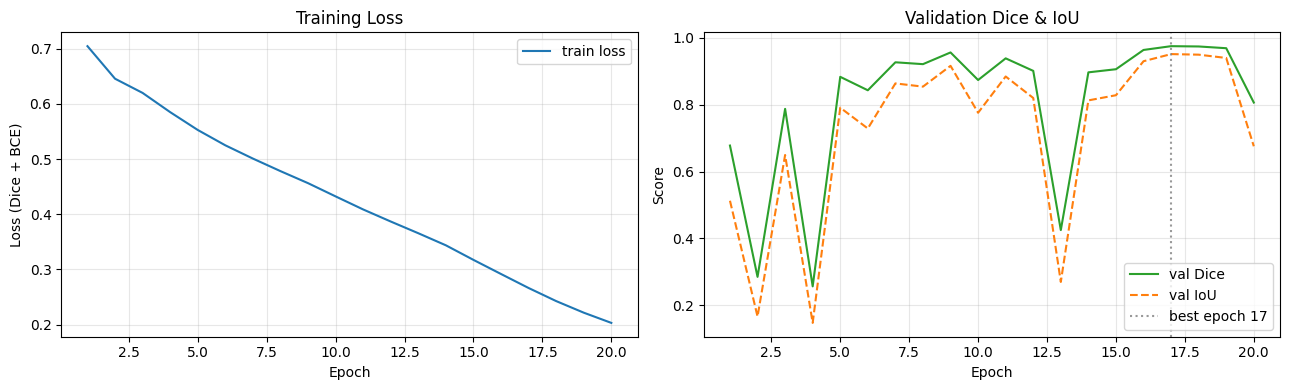

In [11]:
import json

run_dir = PROJECT_DIR / "runs/baseline_2d_e20"   # ← change to your run
history_path = run_dir / 'history.json'
assert history_path.exists(), f'history.json not found in {run_dir.resolve()}'

with open(history_path) as f:
    history = json.load(f)

epochs     = list(range(1, len(history['train_loss']) + 1))
train_loss = history['train_loss']
val_dice   = history['val_dice']
val_iou    = history['val_iou']

best_epoch = epochs[val_dice.index(max(val_dice))]
print(f'Epochs trained  : {len(epochs)}')
print(f'Best val Dice   : {max(val_dice):.4f}  (epoch {best_epoch})')
print(f'Final val Dice  : {val_dice[-1]:.4f}')
print(f'Train loss      : {train_loss[0]:.4f} → {train_loss[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_loss, color='tab:blue', label='train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Dice + BCE)')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_dice, color='tab:green', label='val Dice')
ax2.plot(epochs, val_iou,  color='tab:orange', label='val IoU', linestyle='--')
ax2.axvline(best_epoch, linestyle=':', color='gray', alpha=0.8, label=f'best epoch {best_epoch}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('Validation Dice & IoU')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
import torch
from eval import evaluate

device = 'cpu'
checkpoint_path = run_dir / 'best.pt'
assert checkpoint_path.exists(), f'best.pt not found in {run_dir.resolve()}'

state = torch.load(checkpoint_path, map_location=device)
model_eval = UNet2D(in_channels=4, out_channels=1, base_channels=16)
model_eval.load_state_dict(state['model_state_dict'])
model_eval.eval()

print(f'Checkpoint from  : epoch {state["epoch"]}')
print(f'Saved best_dice  : {state["best_dice"]:.4f}')

# Evaluate on the same val_loader built above
metrics = evaluate(model_eval, val_loader, device=device)
print()
print('─' * 36)
print(f'  {"Metric":<14} {"Value":>8}')
print('─' * 36)
for name, val in metrics.items():
    print(f'  {name:<14} {val:>8.4f}')
print('─' * 36)

Checkpoint from  : epoch 17
Saved best_dice  : 0.9751

────────────────────────────────────
  Metric            Value
────────────────────────────────────
  dice             0.9751
  iou              0.9513
  precision        0.9777
  recall           0.9725
────────────────────────────────────


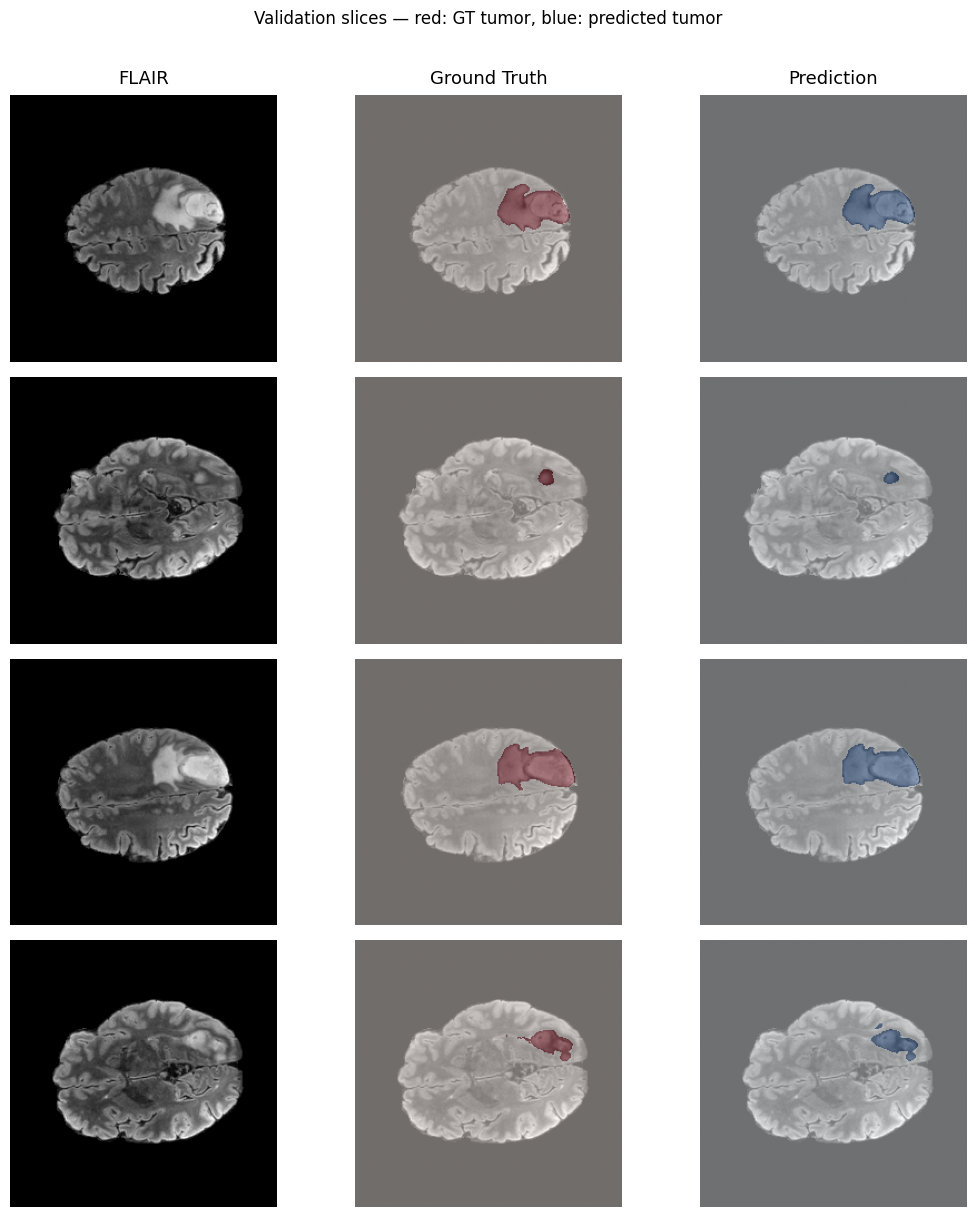

In [13]:
# Visual comparison: FLAIR | Ground Truth | Prediction
# Run a forward pass on one validation batch

xb_vis, yb_vis = next(iter(val_loader))

with torch.no_grad():
    preds_vis = (torch.sigmoid(model_eval(xb_vis)) >= 0.5).float()

n_show = min(4, xb_vis.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(11, 3 * n_show))

col_titles = ['FLAIR', 'Ground Truth', 'Prediction']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, pad=8)

for i in range(n_show):
    flair = xb_vis[i, 3].numpy()   # channel index 3 = FLAIR
    gt    = yb_vis[i, 0].numpy()
    pred  = preds_vis[i, 0].numpy()

    dice_i = (2 * (pred * gt).sum() + 1e-6) / (pred.sum() + gt.sum() + 1e-6)

    axes[i, 0].imshow(flair, cmap='gray')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(flair, cmap='gray')
    axes[i, 1].imshow(gt, cmap='Reds', alpha=0.45)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(flair, cmap='gray')
    axes[i, 2].imshow(pred, cmap='Blues', alpha=0.45)
    axes[i, 2].set_xlabel(f'Dice = {dice_i:.3f}', fontsize=10)
    axes[i, 2].axis('off')

plt.suptitle('Validation slices — red: GT tumor, blue: predicted tumor', y=1.01)
plt.tight_layout()
plt.show()

## Stage E — Multi-Model Comparison (4 configurations)

We compare **4 model × loss configurations** on the combined BraTS dataset (2 cases, 133 tumor slices, 80/20 slice-level split):

| Config | Model | Loss | Params |
|--------|-------|------|--------|
| 1 | UNet2D | DiceBCE | 486,913 |
| 2 | AttentionUNet2D | DiceBCE | 498,341 |
| 3 | HybridUNet2D | DiceBCE | 2,836,629 |
| 4 | HybridUNet2D | FocalTversky | 2,836,629 |

Training was run via `compare_models.py` (30 epochs, batch 4, Adam lr=1e-3, patience=10).
Results are saved in `runs/{config}/history.json`.

In [ ]:
import json, time, torch
from pathlib import Path
from data import build_dataset_from_cases, discover_case_paths
from dataset import BraTS2DSliceDataset, make_loaders
from eval import evaluate
from train import set_seed, train_one_epoch

# ── Configuration ──────────────────────────────────────────────────
CONFIGS = [
    {"name": "unet_dicebce",         "model": "unet",           "loss": "dicebce",        "epochs": 30},
    {"name": "attn_dicebce",         "model": "attention_unet", "loss": "dicebce",         "epochs": 30},
    {"name": "hybrid_dicebce",       "model": "hybrid",         "loss": "dicebce",         "epochs": 30},
    {"name": "hybrid_focal_tversky", "model": "hybrid",         "loss": "focal_tversky",   "epochs": 30},
]
EPOCHS, BATCH_SIZE, SEED = 30, 4, 42  # EPOCHS = default fallback
BASE_CHANNELS, LR = 16, 1e-3
PATIENCE, MIN_DELTA = 10, 0.001

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Build combined dataset from both BraTS cases ──────────────────
case_paths = sorted(Path(".").glob("BraTS2021_*.tar"))
print(f"Found {len(case_paths)} BraTS cases: {[p.name for p in case_paths]}")

X_all, y_all, summary = build_dataset_from_cases(case_paths)
print(f"Combined dataset: X={X_all.shape}, y={y_all.shape}")
for s in summary:
    print(f"  {s['case_id']}: {s['num_slices']} slices")

train_loader, val_loader = make_loaders(X_all, y_all, batch_size=BATCH_SIZE,
                                        val_ratio=0.2, seed=SEED)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# ── Model & Loss factories ────────────────────────────────────────
def make_model(name):
    kw = dict(in_channels=4, out_channels=1, base_channels=BASE_CHANNELS)
    if name == "unet":           return UNet2D(**kw)
    if name == "attention_unet": return AttentionUNet2D(**kw)
    if name == "hybrid":         return HybridUNet2D(**kw, num_heads=4,
                                        num_transformer_layers=2, dim_feedforward=256)

def make_loss(name):
    if name == "dicebce":       return DiceBCELoss()
    if name == "focal_tversky": return FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=0.75)

# ── Train all configurations ──────────────────────────────────────
all_histories = {}

for cfg in CONFIGS:
    run_dir = Path(f"runs/{cfg['name']}")
    history_path = run_dir / "history.json"

    # Skip if already trained
    if history_path.exists():
        with open(history_path) as f:
            all_histories[cfg["name"]] = json.load(f)
        n_ep = len(all_histories[cfg["name"]]["val_dice"])
        best = max(all_histories[cfg["name"]]["val_dice"])
        print(f"\n✓ {cfg['name']} — already trained ({n_ep} epochs, best Dice {best:.4f}), skipping.")
        continue

    run_dir.mkdir(parents=True, exist_ok=True)
    model = make_model(cfg["model"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    loss_fn = make_loss(cfg["loss"])
    n_params = sum(p.numel() for p in model.parameters())

    print(f"\n{'='*60}")
    print(f"Training: {cfg['name']}  |  params: {n_params:,}  |  loss: {cfg['loss']}")
    print(f"{'='*60}")

    history = {"train_loss": [], "val_dice": [], "val_iou": [],
               "val_precision": [], "val_recall": []}
    best_dice, patience_counter = -1.0, 0

    cfg_epochs = cfg.get("epochs", EPOCHS)
    for epoch in range(1, cfg_epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        metrics = evaluate(model, val_loader, device)
        elapsed = time.time() - t0

        history["train_loss"].append(train_loss)
        for k in ["val_dice", "val_iou", "val_precision", "val_recall"]:
            history[k].append(metrics[k.replace("val_", "")])

        dice = metrics["dice"]
        marker = ""
        if dice > best_dice + MIN_DELTA:
            best_dice = dice
            patience_counter = 0
            marker = " ★ best"
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                         "best_dice": best_dice}, run_dir / "best.pt")
        else:
            patience_counter += 1

        print(f"  Epoch {epoch:02d}/{cfg_epochs} | loss {train_loss:.4f} | "
              f"Dice {dice:.4f} | IoU {metrics['iou']:.4f} | "
              f"{elapsed:.1f}s{marker}", flush=True)

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE})")
            break

    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)
    all_histories[cfg["name"]] = history
    print(f"  → Saved to {run_dir}/")

print("\n✅ All configurations done.")

In [ ]:
# ── Load all histories (in case we skipped training above) ────────
import json
from pathlib import Path

LABELS = {
    "unet_dicebce":         "UNet2D + DiceBCE",
    "attn_dicebce":         "AttentionUNet2D + DiceBCE",
    "hybrid_dicebce":       "HybridUNet2D + DiceBCE",
    "hybrid_focal_tversky": "HybridUNet2D + FocalTversky",
}
COLORS = {
    "unet_dicebce":         "#1A73E8",
    "attn_dicebce":         "#E37400",
    "hybrid_dicebce":       "#1E8E3E",
    "hybrid_focal_tversky": "#D93025",
}

histories = {}
for key in LABELS:
    p = Path(f"runs/{key}/history.json")
    if p.exists():
        with open(p) as f:
            histories[key] = json.load(f)

# ── Plot 1: Training Loss curves ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for key, hist in histories.items():
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], label=LABELS[key], color=COLORS[key], linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Training Loss", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Plot 2: Validation Dice curves ───────────────────────────────
ax = axes[1]
for key, hist in histories.items():
    epochs = range(1, len(hist["val_dice"]) + 1)
    best_ep = hist["val_dice"].index(max(hist["val_dice"])) + 1
    ax.plot(epochs, hist["val_dice"], label=LABELS[key], color=COLORS[key], linewidth=2)
    ax.axvline(best_ep, color=COLORS[key], linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Dice Score", fontsize=12)
ax.set_title("Validation Dice", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Plot 3: Validation IoU curves ────────────────────────────────
ax = axes[2]
for key, hist in histories.items():
    epochs = range(1, len(hist["val_iou"]) + 1)
    ax.plot(epochs, hist["val_iou"], label=LABELS[key], color=COLORS[key], linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("IoU Score", fontsize=12)
ax.set_title("Validation IoU", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Summary table: Best metrics per configuration ────────────────
PARAMS = {
    "unet_dicebce": 486_913,
    "attn_dicebce": 498_341,
    "hybrid_dicebce": 2_836_629,
    "hybrid_focal_tversky": 2_836_629,
}

print(f"{'Model':<30s} {'Loss':<16s} {'Params':>10s} {'Best Dice':>10s} "
      f"{'Best IoU':>10s} {'Best Epoch':>10s}")
print("─" * 90)

for key, hist in histories.items():
    best_dice = max(hist["val_dice"])
    best_ep = hist["val_dice"].index(best_dice) + 1
    best_iou = hist["val_iou"][best_ep - 1]
    model_name, loss_name = LABELS[key].split(" + ")
    print(f"{model_name:<30s} {loss_name:<16s} {PARAMS[key]:>10,} "
          f"{best_dice:>10.4f} {best_iou:>10.4f} {best_ep:>10d}")

print("─" * 90)
winner = max(histories, key=lambda k: max(histories[k]["val_dice"]))
print(f"\n🏆 Best model: {LABELS[winner]} — Dice {max(histories[winner]['val_dice']):.4f}")